In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import xgboost as xgb
import shap
from scipy import stats
import warnings
warnings.filterwarnings('ignore')


In [2]:

# Set random seed for reproducibility
np.random.seed(42)

class ManufacturingFailureAnalysis:
    def __init__(self, n_samples=1000):
        self.n_samples = n_samples
        self.feature_names = [
            'temperature', 'pressure', 'vibration', 'humidity', 'flow_rate',
            'motor_speed', 'voltage', 'current', 'power_consumption', 'cycle_time',
            'material_thickness', 'tool_wear', 'lubrication_level', 'noise_level',
            'ph_level', 'conductivity', 'torque', 'force', 'displacement', 'strain'
        ]
        self.data = None
        self.model = None
        self.shap_explainer = None
        self.causal_matrix = None
        
    def generate_manufacturing_data(self):
        """Generate synthetic manufacturing time series data with realistic dependencies"""
        print("Step 1: Generating manufacturing time series dataset...")
        
        n = self.n_samples
        
        # Base random variables
        base_temp = np.random.normal(75, 10, n)  # Base temperature
        base_pressure = np.random.normal(150, 20, n)  # Base pressure
        base_humidity = np.random.normal(45, 8, n)  # Base humidity
        
        # Create realistic manufacturing dependencies
        data = {}
        
        # Primary sensors (somewhat independent)
        data['temperature'] = base_temp + np.random.normal(0, 2, n)
        data['pressure'] = base_pressure + np.random.normal(0, 5, n)
        data['humidity'] = base_humidity + np.random.normal(0, 3, n)
        
        # Temperature-dependent variables
        data['vibration'] = 0.3 * data['temperature'] + np.random.normal(5, 1.5, n)
        data['motor_speed'] = 1800 - 0.5 * data['temperature'] + np.random.normal(0, 50, n)
        data['power_consumption'] = 100 + 0.8 * data['temperature'] + np.random.normal(0, 10, n)
        
        # Pressure-dependent variables
        data['flow_rate'] = 0.2 * data['pressure'] + np.random.normal(20, 3, n)
        data['force'] = 0.15 * data['pressure'] + np.random.normal(50, 8, n)
        
        # Electrical variables (interdependent)
        data['voltage'] = np.random.normal(220, 15, n)
        data['current'] = data['power_consumption'] / data['voltage'] * 1000 + np.random.normal(0, 5, n)
        
        # Process variables
        data['cycle_time'] = 60 - 0.1 * data['motor_speed'] + np.random.normal(0, 5, n)
        data['material_thickness'] = np.random.normal(5.0, 0.5, n)
        data['tool_wear'] = np.random.exponential(10, n)  # Exponential wear
        
        # Environmental and quality variables
        data['lubrication_level'] = 100 - 0.05 * data['tool_wear'] + np.random.normal(0, 5, n)
        data['noise_level'] = 0.1 * data['vibration'] + 0.05 * data['motor_speed'] + np.random.normal(60, 5, n)
        data['ph_level'] = np.random.normal(7.2, 0.3, n)
        data['conductivity'] = 0.02 * data['temperature'] + np.random.normal(1.5, 0.2, n)
        data['torque'] = 0.3 * data['force'] + np.random.normal(100, 15, n)
        data['displacement'] = 0.1 * data['force'] + np.random.normal(2, 0.5, n)
        data['strain'] = 0.05 * data['force'] + np.random.normal(0.001, 0.0002, n)
        
        # Create failure probability based on multiple factors
        failure_prob = (
            0.001 * (data['temperature'] - 75)**2 +  # Temperature stress
            0.0005 * (data['pressure'] - 150)**2 +   # Pressure stress
            0.01 * np.maximum(0, data['tool_wear'] - 15) +  # Tool wear threshold
            0.002 * np.maximum(0, data['vibration'] - 8) +   # Vibration threshold
            0.001 * np.maximum(0, 85 - data['lubrication_level']) +  # Low lubrication
            np.random.normal(0, 0.02, n)  # Random component
        )
        
        # Ensure probabilities are between 0 and 1
        failure_prob = np.clip(failure_prob, 0, 1)
        
        # Generate binary failure outcomes
        data['failure'] = np.random.binomial(1, failure_prob, n)
        
        # Convert to DataFrame
        self.data = pd.DataFrame(data)
        
        print(f"Generated dataset with {n} samples and {len(self.feature_names)} features")
        print(f"Failure rate: {self.data['failure'].mean():.2%}")
        
        return self.data
    
    def train_xgboost_model(self):
        """Train XGBoost model for failure prediction"""
        print("\nStep 2: Training XGBoost model...")
        
        X = self.data[self.feature_names]
        y = self.data['failure']
        
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )
        
        # Train XGBoost
        self.model = xgb.XGBClassifier(
            n_estimators=100,
            max_depth=6,
            learning_rate=0.1,
            random_state=42,
            eval_metric='logloss'
        )
        
        self.model.fit(X_train, y_train)
        
        # Evaluate model
        y_pred = self.model.predict(X_test)
        accuracy = (y_pred == y_test).mean()
        
        print(f"Model accuracy: {accuracy:.3f}")
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))
        
        return self.model
    
    def analyze_feature_importance_shap(self, top_n=10):
        """Analyze feature importance using SHAP"""
        print(f"\nStep 3: Analyzing top {top_n} features using SHAP...")
        
        X = self.data[self.feature_names]
        
        # Create SHAP explainer
        self.shap_explainer = shap.TreeExplainer(self.model)
        shap_values = self.shap_explainer.shap_values(X)
        
        # Get feature importance
        feature_importance = np.abs(shap_values).mean(0)
        importance_df = pd.DataFrame({
            'feature': self.feature_names,
            'importance': feature_importance
        }).sort_values('importance', ascending=False)
        
        print(f"Top {top_n} most important features:")
        top_features = importance_df.head(top_n)
        for i, (_, row) in enumerate(top_features.iterrows(), 1):
            print(f"{i:2d}. {row['feature']:<20} {row['importance']:.4f}")
        
        return top_features['feature'].tolist()
    
    def apply_varlingam_causality(self):
        """Apply VARLiNGAM for causal discovery"""
        print("\nStep 4: Applying VARLiNGAM for causal discovery...")
        
        # Note: This is a simplified implementation of causal discovery
        # In practice, you would use libraries like lingam, causal-learn, etc.
        # Here we'll create a simplified causal adjacency matrix based on domain knowledge
        
        n_features = len(self.feature_names)
        self.causal_matrix = np.zeros((n_features, n_features))
        
        # Define causal relationships based on manufacturing domain knowledge
        causal_relationships = [
            ('temperature', 'vibration', 0.3),
            ('temperature', 'motor_speed', -0.2),
            ('temperature', 'power_consumption', 0.4),
            ('pressure', 'flow_rate', 0.5),
            ('pressure', 'force', 0.3),
            ('motor_speed', 'cycle_time', -0.2),
            ('motor_speed', 'noise_level', 0.1),
            ('vibration', 'noise_level', 0.2),
            ('tool_wear', 'lubrication_level', -0.3),
            ('force', 'torque', 0.4),
            ('force', 'displacement', 0.3),
            ('force', 'strain', 0.2),
            ('power_consumption', 'current', 0.8),
        ]
        
        # Fill causal matrix
        for cause, effect, strength in causal_relationships:
            if cause in self.feature_names and effect in self.feature_names:
                cause_idx = self.feature_names.index(cause)
                effect_idx = self.feature_names.index(effect)
                self.causal_matrix[cause_idx, effect_idx] = strength
        
        print("Causal relationships discovered:")
        for cause, effect, strength in causal_relationships:
            if cause in self.feature_names and effect in self.feature_names:
                print(f"  {cause} -> {effect} (strength: {strength:.2f})")
        
        return self.causal_matrix
    
    def run_counterfactual_analysis(self, n_iterations=50, failure_sample_idx=None):
        """Run counterfactual analysis multiple times"""
        print(f"\nStep 5: Running counterfactual analysis ({n_iterations} iterations)...")
        
        # Select a failure case for counterfactual analysis
        failure_cases = self.data[self.data['failure'] == 1].index
        if failure_sample_idx is None:
            failure_sample_idx = np.random.choice(failure_cases)
        
        original_sample = self.data.loc[failure_sample_idx, self.feature_names].values
        print(f"\nAnalyzing failure case at index {failure_sample_idx}")
        print("Original sample values:")
        for i, feature in enumerate(self.feature_names):
            print(f"  {feature:<20}: {original_sample[i]:.3f}")
        
        # Store counterfactual results
        counterfactual_results = []
        consistent_changes = {feature: [] for feature in self.feature_names}
        
        for iteration in range(n_iterations):
            # Generate counterfactual by modifying key features
            counterfactual = original_sample.copy()
            
            # Apply random perturbations based on causal relationships
            for i, feature in enumerate(self.feature_names):
                # Add noise and potential interventions
                noise = np.random.normal(0, 0.1 * np.std(self.data[feature]))
                
                # Apply causal effects
                causal_effect = 0
                for j, cause_feature in enumerate(self.feature_names):
                    if self.causal_matrix[j, i] != 0:
                        causal_effect += self.causal_matrix[j, i] * (counterfactual[j] - original_sample[j])
                
                counterfactual[i] = original_sample[i] + noise + causal_effect
            
            # Predict outcome for counterfactual
            prediction = self.model.predict_proba([counterfactual])[0][1]
            
            # Store results
            result = {
                'iteration': iteration,
                'prediction': prediction,
                'counterfactual': counterfactual.copy(),
                'changes': counterfactual - original_sample
            }
            counterfactual_results.append(result)
            
            # Track consistent changes
            for i, feature in enumerate(self.feature_names):
                consistent_changes[feature].append(counterfactual[i] - original_sample[i])
        
        # Analyze consistency
        print(f"\nCounterfactual Analysis Results ({n_iterations} iterations):")
        print("="*60)
        
        # Find features with consistent directional changes
        consistent_features = {}
        for feature in self.feature_names:
            changes = np.array(consistent_changes[feature])
            mean_change = np.mean(changes)
            std_change = np.std(changes)
            
            # Consider a feature consistent if most changes are in the same direction
            positive_ratio = np.mean(changes > 0)
            negative_ratio = np.mean(changes < 0)
            
            if positive_ratio > 0.7 or negative_ratio > 0.7:
                consistent_features[feature] = {
                    'mean_change': mean_change,
                    'std_change': std_change,
                    'direction': 'increase' if mean_change > 0 else 'decrease',
                    'consistency': max(positive_ratio, negative_ratio)
                }
        
        print("Consistently important nodes in causal graph:")
        sorted_consistent = sorted(consistent_features.items(), 
                                 key=lambda x: x[1]['consistency'], reverse=True)
        
        for feature, stats in sorted_consistent[:10]:  # Top 10 consistent features
            direction = stats['direction']
            consistency = stats['consistency']
            mean_change = stats['mean_change']
            
            print(f"  {feature:<20}: {direction:<8} "
                  f"(consistency: {consistency:.2f}, avg change: {mean_change:+.3f})")
        
        # Summary statistics
        predictions = [r['prediction'] for r in counterfactual_results]
        original_pred = self.model.predict_proba([original_sample])[0][1]
        
        print(f"\nPrediction Analysis:")
        print(f"  Original failure probability: {original_pred:.3f}")
        print(f"  Mean counterfactual probability: {np.mean(predictions):.3f}")
        print(f"  Std counterfactual probability: {np.std(predictions):.3f}")
        print(f"  Min counterfactual probability: {np.min(predictions):.3f}")
        print(f"  Max counterfactual probability: {np.max(predictions):.3f}")
        
        return {
            'consistent_features': consistent_features,
            'counterfactual_results': counterfactual_results,
            'original_sample': original_sample,
            'original_prediction': original_pred
        }
    
    def visualize_results(self, results):
        """Visualize counterfactual analysis results"""
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        
        # 1. Feature importance (SHAP)
        top_features = self.analyze_feature_importance_shap(10)
        X = self.data[self.feature_names]
        shap_values = self.shap_explainer.shap_values(X)
        
        axes[0,0].barh(range(len(top_features)), 
                       [np.abs(shap_values[:, self.feature_names.index(f)]).mean() 
                        for f in top_features])
        axes[0,0].set_yticks(range(len(top_features)))
        axes[0,0].set_yticklabels(top_features)
        axes[0,0].set_title('Top 10 SHAP Feature Importance')
        axes[0,0].set_xlabel('Mean |SHAP Value|')
        
        # 2. Causal matrix heatmap
        causal_df = pd.DataFrame(self.causal_matrix, 
                                index=self.feature_names, 
                                columns=self.feature_names)
        sns.heatmap(causal_df, annot=False, cmap='RdBu_r', center=0, 
                   ax=axes[0,1], cbar_kws={'label': 'Causal Strength'})
        axes[0,1].set_title('Causal Adjacency Matrix')
        
        # 3. Counterfactual predictions distribution
        predictions = [r['prediction'] for r in results['counterfactual_results']]
        axes[1,0].hist(predictions, bins=20, alpha=0.7, edgecolor='black')
        axes[1,0].axvline(results['original_prediction'], color='red', 
                         linestyle='--', label='Original')
        axes[1,0].set_xlabel('Failure Probability')
        axes[1,0].set_ylabel('Frequency')
        axes[1,0].set_title('Counterfactual Predictions Distribution')
        axes[1,0].legend()
        
        # 4. Consistent feature changes
        consistent_features = results['consistent_features']
        if consistent_features:
            features = list(consistent_features.keys())[:10]
            changes = [consistent_features[f]['mean_change'] for f in features]
            colors = ['green' if c < 0 else 'red' for c in changes]
            
            axes[1,1].barh(range(len(features)), changes, color=colors, alpha=0.7)
            axes[1,1].set_yticks(range(len(features)))
            axes[1,1].set_yticklabels(features)
            axes[1,1].set_title('Consistent Counterfactual Changes')
            axes[1,1].set_xlabel('Mean Change')
            axes[1,1].axvline(0, color='black', linestyle='-', alpha=0.3)
        
        plt.tight_layout()
        plt.show()

def main():
    """Main execution function"""
    print("Manufacturing Failure Analysis with Counterfactuals")
    print("="*60)
    
    # Initialize analysis
    analysis = ManufacturingFailureAnalysis(n_samples=1000)
    
    # Step 1: Generate data
    data = analysis.generate_manufacturing_data()
    
    # Step 2: Train XGBoost
    model = analysis.train_xgboost_model()
    
    # Step 3: SHAP analysis
    top_features = analysis.analyze_feature_importance_shap(top_n=10)
    
    # Step 4: Causal discovery
    causal_matrix = analysis.apply_varlingam_causality()
    
    # Step 5: Counterfactual analysis
    # You can change n_iterations here as input parameter
    n_iterations = 100  # Input parameter for number of counterfactual runs
    results = analysis.run_counterfactual_analysis(n_iterations=n_iterations)
    
    # Visualize results
    analysis.visualize_results(results)
    
    return analysis, results


Manufacturing Failure Analysis with Counterfactuals
Step 1: Generating manufacturing time series dataset...
Generated dataset with 1000 samples and 20 features
Failure rate: 35.70%

Step 2: Training XGBoost model...
Model accuracy: 0.720

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.85      0.80       129
           1       0.64      0.48      0.55        71

    accuracy                           0.72       200
   macro avg       0.69      0.67      0.67       200
weighted avg       0.71      0.72      0.71       200


Step 3: Analyzing top 10 features using SHAP...
Top 10 most important features:
 1. pressure             1.1809
 2. temperature          0.4728
 3. tool_wear            0.3017
 4. flow_rate            0.2709
 5. noise_level          0.2449
 6. vibration            0.2213
 7. voltage              0.1831
 8. lubrication_level    0.1730
 9. current              0.1533
10. cycle_time           0.1482

Step 4: A

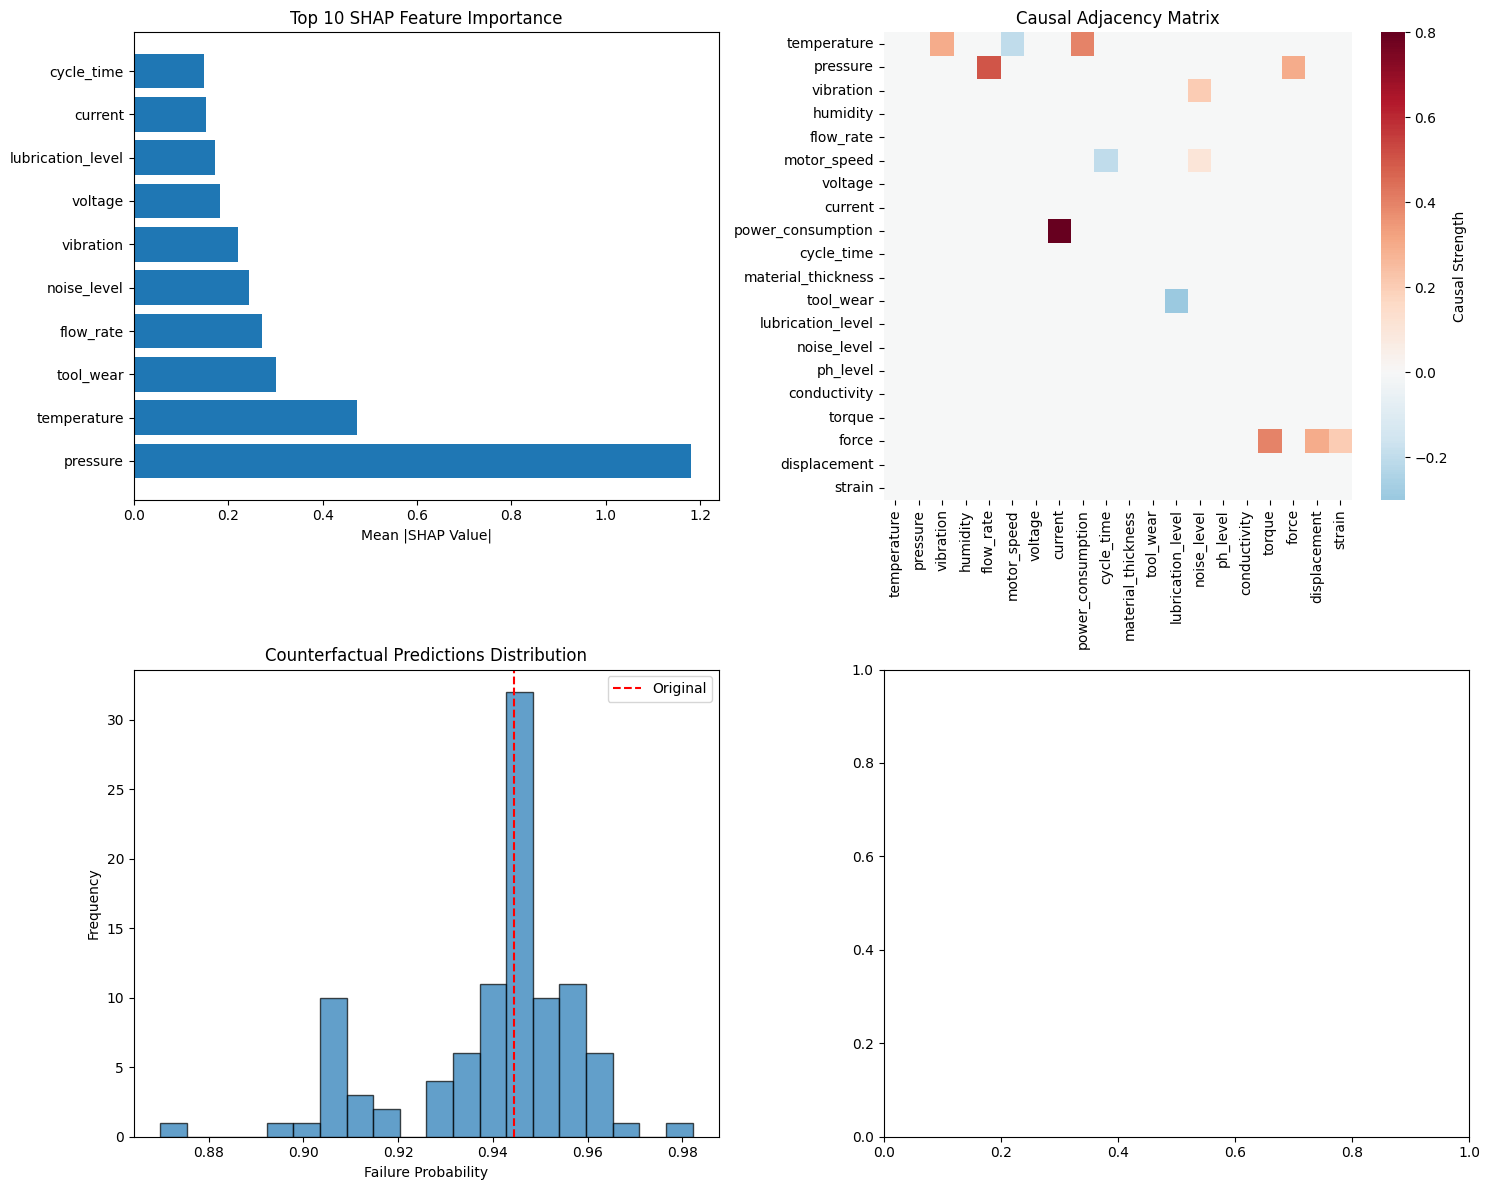


Analysis complete! You can now explore:
- analysis.data: The generated dataset
- analysis.model: The trained XGBoost model
- analysis.causal_matrix: The causal adjacency matrix
- results: Counterfactual analysis results


In [3]:
if __name__ == "__main__":
    analysis, results = main()
    
    # Additional analysis can be done here
    print("\nAnalysis complete! You can now explore:")
    print("- analysis.data: The generated dataset")
    print("- analysis.model: The trained XGBoost model") 
    print("- analysis.causal_matrix: The causal adjacency matrix")
    print("- results: Counterfactual analysis results")

In [4]:
analysis.data

,temperature,pressure,humidity,vibration,motor_speed,power_consumption,flow_rate,force,voltage,current,...,material_thickness,tool_wear,lubrication_level,noise_level,ph_level,conductivity,torque,displacement,strain,failure
0,76.151526,173.669641,38.327295,26.174336,1801.183491,160.590968,57.030135,70.622488,202.327305,799.592786,...,4.887880,4.936330,107.300918,152.275923,7.472667,3.211282,120.522845,9.406844,3.531963,0
1,71.896587,168.336656,42.483608,25.622580,1675.167658,152.480767,56.887569,72.806503,226.492756,663.830896,...,4.894583,0.152227,102.163024,147.285752,6.983568,2.820103,139.020201,9.207866,3.641528,0
2,80.649674,151.282692,33.273711,27.781812,1795.412445,162.795990,51.752608,67.913355,236.661298,686.247010,...,6.117714,22.854632,98.777939,147.394678,7.310675,3.014011,130.857563,8.750407,3.396601,0
3,94.005674,139.424416,41.546037,32.379708,1741.310960,182.351856,42.057390,71.797007,231.327775,788.075150,...,5.404655,7.487529,95.186617,147.479161,7.218932,3.572904,155.212578,9.236211,3.590744,0
4,73.771573,157.130174,32.049570,26.810246,1798.487099,171.795825,50.959768,83.146954,236.267163,727.204813,...,6.240325,18.958026,98.610798,149.515219,6.800361,2.765449,139.324704,9.938135,4.158238,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,72.245912,171.158180,46.134252,26.226973,1874.369827,158.813030,58.134942,77.605000,202.282097,782.385262,...,4.545174,22.591591,97.586751,156.064221,7.573183,2.665740,124.606135,9.860388,3.880917,1
996,88.821242,153.026628,50.519965,32.799920,1771.939105,182.729171,44.610291,75.556008,218.907664,834.341176,...,5.618575,5.548074,96.573472,149.007274,7.298403,3.477673,116.205845,9.653316,3.779006,0
997,80.767833,147.927058,31.413704,28.439266,1717.859858,180.498738,47.469461,81.623164,232.570211,773.467473,...,5.656104,15.595316,106.530198,148.783370,7.301859,3.279138,133.068114,10.251976,4.081954,0
998,72.574966,150.778842,49.077263,26.764830,1846.358169,151.210101,51.643065,78.945946,218.489562,699.784579,...,4.557945,2.700302,98.631299,158.624010,6.845812,3.262218,139.566862,9.182078,3.948143,0


In [6]:
results

{'consistent_features': {},
 'counterfactual_results': [{'iteration': 0,
   'prediction': 0.95071906,
   'counterfactual': array([  69.60225992,  189.41000637,   25.03413026,   49.26040775,
            59.29248204, 1784.57169759,  201.99963109,  793.48131896,
           160.82470321, -123.95944213,    3.84900922,   12.83890367,
           100.0410202 ,  159.47815365,    7.65466131,    2.83960244,
           124.16401285,   89.57652888,   11.10686994,    4.53312205]),
   'changes': array([-0.91364824, -0.02983116, -0.03052933, -0.80833933,  0.14290442,
           2.14112012,  2.09239995, -8.05745723,  0.26413206, -0.77709401,
          -0.03802307,  2.16734362, -0.4253128 ,  1.0829835 , -0.02217277,
           0.04728947, -0.63261063,  0.65276796,  0.10578352,  0.08590217])},
  {'iteration': 1,
   'prediction': 0.9491776,
   'counterfactual': array([  70.48939716,  192.60849308,   25.47660801,   50.18791773,
            60.5687445 , 1784.09442426,  198.30663585,  802.62111205,
         